## **Import Library**

In [1]:
import string
import csv
import requests
import pandas as pd
import numpy as np
import nltk
import matplotlib.pyplot as plt
from io import StringIO
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from mpstemmer import MPStemmer
from gensim.models import Word2Vec
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.naive_bayes import BernoulliNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
import tensorflow 
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from keras.models import Sequential
from keras.layers import LSTM, Embedding, Dense, Bidirectional, TextVectorization

## **Loading Dataset**

In [2]:
tokopedia_df = pd.read_csv("ulasan_tokopedia.csv")
tokopedia_df

,Review
0,Aplikasi olshop terburuk dalam memperlakukan p...
1,"Tolong dioptimalkan dong, punya saya beberapa ..."
2,Barang sy telat dikirim. Setelah sy masukkan l...
3,Sekarang agak kecewa masalah fitur halaman dep...
4,"Aplikasinya berat banget, padahal hp saya engg..."
...,...
3495,Per 2-11-22 Mungkin pelanggan setia toped di s...
3496,Jujur gw suka produk lokal kayak TOKOPEDIA gin...
3497,Langganan PLUS rasanya mengecewakan. Cashback ...
3498,Bagus Banget.. Foto dengan barang yang sudah s...


## **Preprocessing Text**

In [3]:
nltk.download("punkt_tab")
nltk.download("stopwords")

# 1. Membuat Fungsi Case Folding 
def case_folding(text):
    text = text.lower()
    return text


# 2. Membuat Fungsi untuk Menghapus Angka
def delete_number (text):
    text = "".join([char for char in text if not char.isdigit() ])
    return text


# 3. Membuat Fungsi untuk Menghapus Tanda Baca
def remove_punctuation(text):
    punctuation_set = set(string.punctuation)
    text = "".join([char for char in text if char not in punctuation_set])
    return text


# 4. Membuat Fungsi untuk Tokenizing
def tokenize(text):
    text = word_tokenize(text)
    return text


# 5. Membuat Fungsi untuk Stopword Removal
def stopword(text):
    factory = StopWordRemoverFactory()
    stopword_sastrawi = factory.get_stop_words()
    important_word = [word for word in text if word.lower() not in stopword_sastrawi]
    text = " ".join(important_word)
    return text

# 6. Membuat Fungsi untuk Stemming
def stemming(text):
    stemmer = MPStemmer()
    text = stemmer.stem_kalimat(text)
    return text


# 7. Membuat Fungsi untuk Menghapus Slang Word
slangwords = {"@": "di", "abis": "habis", "wtb": "beli", "masi": "masih", "wts": "jual", "wtt": "tukar", "bgt": "banget", "maks": "maksimal"}
def fix_slangwords (text):
    words = text.split()
    fixed_words = []

    for word in words:
        if word in slangwords:
            fixed_words.append(slangwords[word.lower()])
        else:
            fixed_words.append(word)
    
    fixed_text = " ".join(fixed_words)
    return fixed_text



[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\dell\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\dell\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [4]:
tokopedia_df["Text Lower"] = tokopedia_df["Review"].apply(case_folding)

tokopedia_df["No Number"] = tokopedia_df["Text Lower"].apply(delete_number)

tokopedia_df["No Punctuation"] = tokopedia_df["No Number"].apply(remove_punctuation)

tokopedia_df["Tokenize Text"] = tokopedia_df["No Punctuation"].apply(tokenize)

tokopedia_df["Stopword Text"] = tokopedia_df["Tokenize Text"].apply(stopword)

tokopedia_df["Stemming Text"] = tokopedia_df["Stopword Text"].apply(stemming)

tokopedia_df["Cleaning Text"] = tokopedia_df["Stemming Text"].apply(fix_slangwords)

## **Pelabelan Text**

In [5]:
# Mengambil lexicon positive

lexicon_positive = {}
response = requests.get('https://raw.githubusercontent.com/angelmetanosaa/dataset/main/lexicon_positive.csv')

if response.status_code == 200:
    reader = csv.reader(StringIO(response.text), delimiter=',')

    for row in reader:
        lexicon_positive[row[0]] = int(row[1])
else:
    print("Failed to fetch positive lexicon data")

In [6]:
# Mengambil lexicon negative

lexicon_negative = {}
response = requests.get("https://raw.githubusercontent.com/angelmetanosaa/dataset/main/lexicon_negative.csv")

if response.status_code == 200:
    reader = csv.reader(StringIO(response.text), delimiter=',')

    for row in reader:
        lexicon_negative[row[0]] = int(row[1])
else:
    print("Failed to fetch negative lexicon data")

In [7]:
# Fungsi sentiment analysis

def sentiment_analysis_lexicon_indonesia (text):
    score = 0
    text = text.split()

    # Cek kata positif
    for word in text:
        if (word in lexicon_positive):
            score = score + lexicon_positive[word]
    
    # Cek kata negatif
    for word in text:
        if (word in lexicon_negative):
            score = score + lexicon_negative[word]
    
    # Menentukan label
    polarity = ''
    if (score >= 0):
        polarity = "Positive"
    elif (score < 0):
        polarity = "Negative"
    
    return score, polarity

In [8]:
# Apply ke dataset
results = tokopedia_df["Cleaning Text"].apply(sentiment_analysis_lexicon_indonesia)
results = list(zip(*results))

tokopedia_df["Polarity Score"] = results[0]
tokopedia_df["Polarity"] = results[1]
labels_category = tokopedia_df["Polarity"].value_counts()
labels_category

Polarity
Negative    2654
Positive     846
Name: count, dtype: int64

In [9]:
# Melakukan Label Encoding pada kolom Polarity
tokopedia_df["Polarity"] = tokopedia_df["Polarity"].replace("Negative", 0)
tokopedia_df["Polarity"] = tokopedia_df["Polarity"].replace("Positive", 1)

C:\Users\dell\AppData\Local\Temp\ipykernel_20624\1750623881.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  tokopedia_df["Polarity"] = tokopedia_df["Polarity"].replace("Positive", 1)


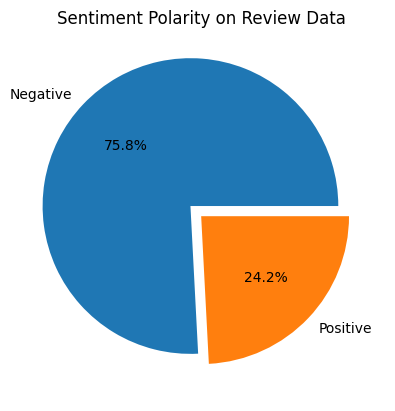

In [10]:
plt.pie(labels_category, labels=["Negative", "Positive"], autopct="%1.1f%%", explode=[0.1, 0])
plt.title("Sentiment Polarity on Review Data")
plt.show()

In [11]:
tokopedia_df

,Review,Text Lower,No Number,No Punctuation,Tokenize Text,Stopword Text,Stemming Text,Cleaning Text,Polarity Score,Polarity
0,Aplikasi olshop terburuk dalam memperlakukan p...,aplikasi olshop terburuk dalam memperlakukan p...,aplikasi olshop terburuk dalam memperlakukan p...,aplikasi olshop terburuk dalam memperlakukan p...,"[aplikasi, olshop, terburuk, dalam, memperlaku...",aplikasi olshop terburuk memperlakukan penggun...,aplikasi olshop buruk laku guna baru bulan lal...,aplikasi olshop buruk laku guna baru bulan lal...,-23,0
1,"Tolong dioptimalkan dong, punya saya beberapa ...","tolong dioptimalkan dong, punya saya beberapa ...","tolong dioptimalkan dong, punya saya beberapa ...",tolong dioptimalkan dong punya saya beberapa f...,"[tolong, dioptimalkan, dong, punya, saya, bebe...",dioptimalkan dong punya beberapa fitur termasu...,optimal dong punya beberapa fitur masuk tokope...,optimal dong punya beberapa fitur masuk tokope...,-7,0
2,Barang sy telat dikirim. Setelah sy masukkan l...,barang sy telat dikirim. setelah sy masukkan l...,barang sy telat dikirim. setelah sy masukkan l...,barang sy telat dikirim setelah sy masukkan la...,"[barang, sy, telat, dikirim, setelah, sy, masu...",barang sy telat dikirim sy masukkan laporan so...,barang sy telat kirim sy masuk lapor solusi ad...,barang sy telat kirim sy masuk lapor solusi ad...,2,1
3,Sekarang agak kecewa masalah fitur halaman dep...,sekarang agak kecewa masalah fitur halaman dep...,sekarang agak kecewa masalah fitur halaman dep...,sekarang agak kecewa masalah fitur halaman dep...,"[sekarang, agak, kecewa, masalah, fitur, halam...",sekarang kecewa masalah fitur halaman depan to...,sekarang kecewa masalah fitur halaman depan to...,sekarang kecewa masalah fitur halaman depan to...,15,1
4,"Aplikasinya berat banget, padahal hp saya engg...","aplikasinya berat banget, padahal hp saya engg...","aplikasinya berat banget, padahal hp saya engg...",aplikasinya berat banget padahal hp saya engga...,"[aplikasinya, berat, banget, padahal, hp, saya...",aplikasinya berat banget padahal hp engga jele...,aplikasi berat banget padahal hp tidak jelek j...,aplikasi berat banget padahal hp tidak jelek j...,-31,0
...,...,...,...,...,...,...,...,...,...,...
3495,Per 2-11-22 Mungkin pelanggan setia toped di s...,per 2-11-22 mungkin pelanggan setia toped di s...,per -- mungkin pelanggan setia toped di seluru...,per mungkin pelanggan setia toped di seluruh ...,"[per, mungkin, pelanggan, setia, toped, di, se...",per mungkin pelanggan setia toped seluruh indo...,per mungkin pelanggan setia toped seluruh indo...,per mungkin pelanggan setia toped seluruh indo...,-4,0
3496,Jujur gw suka produk lokal kayak TOKOPEDIA gin...,jujur gw suka produk lokal kayak tokopedia gin...,jujur gw suka produk lokal kayak tokopedia gin...,jujur gw suka produk lokal kayak tokopedia gin...,"[jujur, gw, suka, produk, lokal, kayak, tokope...",jujur gw suka produk lokal kayak tokopedia gin...,jujur gue suka produk lokal kayak tokopedia be...,jujur gue suka produk lokal kayak tokopedia be...,-38,0
3497,Langganan PLUS rasanya mengecewakan. Cashback ...,langganan plus rasanya mengecewakan. cashback ...,langganan plus rasanya mengecewakan. cashback ...,langganan plus rasanya mengecewakan cashback c...,"[langganan, plus, rasanya, mengecewakan, cashb...",langganan plus rasanya mengecewakan cashback c...,langgan plus rasa kecewa cashback coinnya sama...,langgan plus rasa kecewa cashback coinnya sama...,8,1
3498,Bagus Banget.. Foto dengan barang yang sudah s...,bagus banget.. foto dengan barang yang sudah s...,bagus banget.. foto dengan barang yang sudah s...,bagus banget foto dengan barang yang sudah sam...,"[bagus, banget, foto, dengan, barang, yang, su...",bagus banget foto barang sama barangnya bagus ...,bagus banget foto barang sama barang bagus kua...,bagus banget foto barang sama barang bagus kua...,23,1


## **Data Splitting dan Ekstraksi Fitur**

In [12]:
# Pisahkan data menjadi fitur dan target
X = tokopedia_df["Cleaning Text"]
y = tokopedia_df["Polarity"]


# Membagi dataset menjadi data latih dan data uji
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

"""# Konversi hasil ekstraksi fitur menjadi dataframe
features_df = pd.DataFrame(X_tfidf.toarray(), columns=tfidf.get_feature_names_out())
"""

'# Konversi hasil ekstraksi fitur menjadi dataframe\nfeatures_df = pd.DataFrame(X_tfidf.toarray(), columns=tfidf.get_feature_names_out())\n'

## **Modelling & Evaluation**

In [13]:
# Siapkan Hyperparameter
vocab_size = 10000
embedding_dim = 128
max_length = 200
trunc_type = "post"
padding_type = "post"
oov_tok = '<OOV>'
num_epochs = 50

# Membangun Model
model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim),
    Bidirectional(LSTM(embedding_dim)),
    Dense(embedding_dim, activation="relu"),
    Dense(2, activation="softmax")
])
model.build(input_shape=(None, None))
model.summary()
model.compile(loss="sparse_categorical_crossentropy", optimizer="Adam", metrics=["accuracy"])

# Melakukan setup tokenizer dan sekuens
tokenizer = Tokenizer(num_words=vocab_size, oov_token=oov_tok)
tokenizer.fit_on_texts(X)

sekuens_train = tokenizer.texts_to_sequences(X_train)
sekuens_val = tokenizer.texts_to_sequences(X_test)

X_train_new = pad_sequences(sekuens_train, maxlen = max_length, padding=padding_type, truncating=trunc_type)
X_test_new = pad_sequences(sekuens_val, maxlen = max_length, padding=padding_type, truncating=trunc_type)


# Lakukan pelatihan model
history = model.fit(X_train_new, y_train, epochs=num_epochs, validation_data=(X_test_new, y_test), batch_size=64, verbose=2)

train_loss, train_acc = model.evaluate(X_train_new, y_train, verbose=2)
print(f"Train Accuracy: {train_acc}")

test_lost, test_acc = model.evaluate(X_test_new, y_test, verbose=2)
print(f"Test Accuracy: {test_acc}")


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, None, 128)      │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 256)            │       263,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,576,322 (6.01 MB)

 Trainable params: 1,576,322 (6.01 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
44/44 - 36s - 828ms/step - accuracy: 0.7686 - loss: 0.4986 - val_accuracy: 0.8071 - val_loss: 0.4038
Epoch 2/50
44/44 - 31s - 706ms/step - accuracy: 0.9050 - loss: 0.2312 - val_accuracy: 0.8614 - val_loss: 0.3615
Epoch 3/50
44/44 - 29s - 655ms/step - accuracy: 0.9689 - loss: 0.0799 - val_accuracy: 0.8671 - val_loss: 0.3806
Epoch 4/50
44/44 - 26s - 601ms/step - accuracy: 0.9729 - loss: 0.0679 - val_accuracy: 0.8729 - val_loss: 0.4683
Epoch 5/50
44/44 - 25s - 564ms/step - accuracy: 0.9900 - loss: 0.0313 - val_accuracy: 0.8600 - val_loss: 0.5536
Epoch 6/50
44/44 - 26s - 590ms/step - accuracy: 0.9914 - loss: 0.0237 - val_accuracy: 0.8800 - val_loss: 0.6598
Epoch 7/50
44/44 - 25s - 579ms/step - accuracy: 0.9982 - loss: 0.0061 - val_accuracy: 0.8786 - val_loss: 0.6434
Epoch 8/50
44/44 - 25s - 574ms/step - accuracy: 0.9993 - loss: 0.0042 - val_accuracy: 0.8457 - val_loss: 0.6557
Epoch 9/50
44/44 - 26s - 587ms/step - accuracy: 0.9882 - loss: 0.0324 - val_accuracy: 0.8686 - val_loss: